In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
sns.set_context('notebook')
%config InlineBackend.figure_format = 'retina'   # or 'png'
%config InlineBackend.rc = {'figure.dpi': 92}    # force dpi


from utils.setup_environment import *
from utils.Glider1D import Glider1D, CustomStimuli, RenderedData
from utils.glider_utils import *

from flyvis.utils.activity_utils import LayerActivity


In [3]:
network_view = flyvis.NetworkView(flyvis.results_dir / "flow/0000/000")
network = network_view.init_network()

[2025-10-22 06:44:08] network_view:122 Initialized network view at /home/guardomayas/flyvis_data/results/flow/0000/000
[2025-10-22 06:44:13] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-10-22 06:44:13] chkpt_utils:36 Recovered network state.


In [4]:
# Load the saved data
fps = 24
filename = f'compute_responses/nw_0_ALLgliders_diff_seeds_{fps}_fps.npz'
# filename = f'compute_responses/nw_0_gliders_diff_seeds_{fps}_fps.npz'
data_loaded = np.load(filename, allow_pickle=True)
responses = data_loaded['responses']
df = pd.DataFrame(data_loaded['df'].item())
print(f"Loaded filename: {filename}")
print(f"Loaded responses shape: {responses.shape}") # seeds, seqs, nframes, neurons


Loaded filename: compute_responses/nw_0_ALLgliders_diff_seeds_24_fps.npz
Loaded responses shape: (6, 20, 300, 45669)


In [5]:
responses_layer = LayerActivity(responses, network.connectome, keepref=True)

In [6]:
df['mean_response'] = np.nan
df['max_response'] = np.nan
df['dsi'] = np.nan # Directional Selectivity Index
df['difference'] = np.nan 
rules = df['rule'].unique()
parities = df['parity'].unique()
df.head()

,sequence_idx,rule,direction,parity,vel,seed,T,fps,dt,mean_response,max_response,dsi,difference
0,0,uncorrelated,pd,1,0,1,72,24,0.01,NaN,NaN,NaN,NaN
1,1,uncorrelated,pd,-1,0,1,72,24,0.01,NaN,NaN,NaN,NaN
2,2,uncorrelated,nd,1,0,1,72,24,0.01,NaN,NaN,NaN,NaN
3,3,uncorrelated,nd,-1,0,1,72,24,0.01,NaN,NaN,NaN,NaN
4,4,uniform_edge,pd,1,0,1,72,24,0.01,NaN,NaN,NaN,NaN


Using 451 neurons (excluded 270 edge neurons)


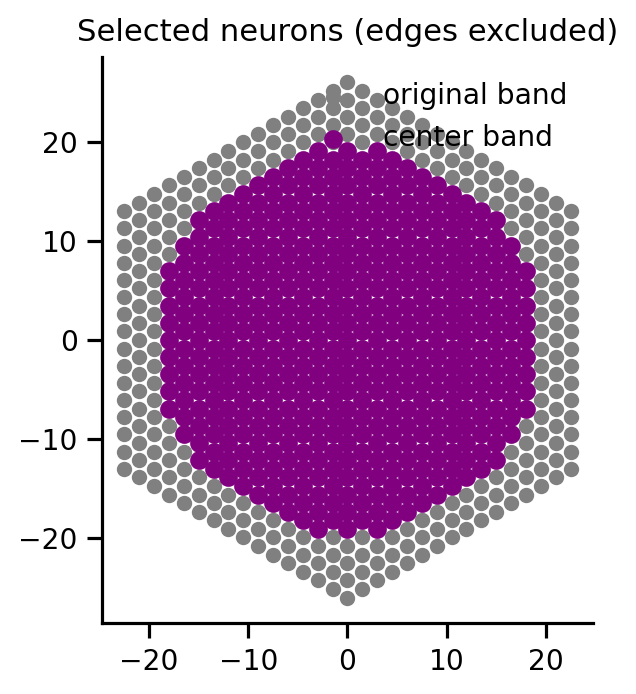

In [7]:
fig, band_indices, u, v= select_bandindices(y_range_tolerance=26)

In [9]:
# =====================================
# PLOTTING FUNCTION
# =====================================
def plot_HS_responses(
    t,
    exc_R,
    inh_R,
    exc_L,
    inh_L,
    R,
    L,
    R_mean,
    L_mean,
    diff,
    dsi,
    cell_type="HSS",
    rule="",
    parity="",
    seed="",
    titlefs=14,
):
    """Plot excitatory, inhibitory, and summed responses for either HSN or HSS."""
    cpal = sns.color_palette("magma", as_cmap=True)

    fig = plt.figure(figsize=(8, 5), layout="constrained", dpi=140)
    fig.suptitle(
        f"{cell_type} responses | rule {rule}, parity {parity}, seed {seed}",
        fontsize=13,
        y=1.03,
    )
    gs = GridSpec(4, 2, figure=fig, width_ratios=(1, 0.7))
    ax0, ax1 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])
    ax2, ax3 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[3, 0])
    ax4 = fig.add_subplot(gs[1:3, 1])

    color_exc = cpal(0.25)
    color_inh = cpal(0.65)
    color_sum = cpal(0.9)

    right_title, left_title = r"$\longrightarrow$", r"$\longleftarrow$"
   

    # --- Rightward motion ---
    ax0.set_title(right_title, fontsize=titlefs + 2)
    ax0.plot(t, exc_R, c=color_exc, label="Exc")
    ax0.plot(t, inh_R, c=color_inh, label="Inh")
    ax1.plot(t, R, c=color_sum, label="Exc−Inh")

    # --- Leftward motion ---
    ax2.set_title(left_title, fontsize=titlefs + 2)
    ax2.plot(t, exc_L, c=color_exc, label="Exc")
    ax2.plot(t, inh_L, c=color_inh, label="Inh")
    ax3.plot(t, L, c=color_sum, label="Exc−Inh")

    # --- Formatting ---
    for ax in [ax0, ax1, ax2, ax3]:
        ax.set_xlim(0, t.max())
        ax.set_xlabel("Time (s)", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.axhline(0, color="k", linestyle="--", lw=1, alpha=0.6)
        ax.set_ylim(-0.5, 0.5)

    # --- Mean bar plot ---
    ax4.bar(
        ["← (Left)", "→ (Right)", "Diff"],
        [L_mean, R_mean, diff],
        color=["lightgray", "darkgray", "k"],
    )
    ax4.set_title(f"Mean responses ({cell_type})", fontsize=titlefs)
    ax4.tick_params(axis="x", labelsize=12)
    ax4.set_ylim(-.75, .75)
    ax4.text(
        0.5,
        0.45,
        f"DSI={dsi:.2f}",
        ha="center",
        va="center",
        fontsize=titlefs - 2,
        fontweight="bold",
    )

    # --- Shared legend ---
    fig.legend(
        handles=[
            plt.Line2D([0], [0], color=color_exc, lw=2, label="Exc"),
            plt.Line2D([0], [0], color=color_inh, lw=2, label="Inh"),
            plt.Line2D([0], [0], color=color_sum, lw=2, label="Sum (Exc−Inh)"),
        ],
        loc="upper left",
        bbox_to_anchor=(0.01, 1.055),
        frameon=False,
        fontsize=titlefs - 2,
    )

    fig.tight_layout()
    plt.show(block=False)


In [27]:
def compute_HS_responses(w_T4, w_T5, T4a_mean, T5a_mean, T4b_mean, T5b_mean):
    HSS_exc = w_T4*T4b_mean + w_T5*T5b_mean
    HSS_inh = w_T4*T4a_mean + w_T5*T5a_mean
    HSS = HSS_exc - HSS_inh

    return HSS_exc, HSS_inh, HSS

def compute_HS_responses_full(w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh,
                              T4a_mean, T5a_mean, T4b_mean, T5b_mean):
    HSS_exc = w_T4_exc*T4b_mean + w_T5_exc*T5b_mean
    HSS_inh = w_T4_inh*T4a_mean + w_T5_inh*T5a_mean
    HSS = HSS_exc - HSS_inh
    return HSS_exc, HSS_inh, HSS

In [17]:
from scipy.ndimage import gaussian_filter1d

plotflag = False
cpal = sns.color_palette("magma", as_cmap=True)
stats_list = []
titlefs = 12
eps = 1e-9
w_T4, w_T5 = 1.0, 1.0  # ON/OFF weights

type1, type2, type3, type4 = "T4a", "T4b", "T5a", "T5b"
T4a, T4b, T5a, T5b = (
    responses_layer[type1],
    responses_layer[type2],
    responses_layer[type3],
    responses_layer[type4],
)

# Expecting array shape: [seed, seq, time, neuron]
T_time = T4a.shape[2]
t = np.arange(0, T_time * df["dt"].iloc[0], df["dt"].iloc[0])  # robust .iloc

for seed_idx, seed in enumerate(df["seed"].unique()):
    for rule in rules:
    #     if not rule.startswith("2pt"):
    #         continue
        for parity in parities:
            # if parity != 1:
            #     continue
            # Get PD/ND sequence indices robustly
            qR = df.query("rule == @rule and direction == 'pd' and parity == @parity and seed == @seed")
            qL = df.query("rule == @rule and direction == 'nd' and parity == @parity and seed == @seed")
            assert len(qR) == 1 and len(qL) == 1, f"Expected exactly one row per query; got {len(qR)} / {len(qL)}"  # FIX 4
            right_idx = int(qR["sequence_idx"].iloc[0])
            left_idx  = int(qL["sequence_idx"].iloc[0])

            # Gather responses across neurons
            act_T4a_R, act_T4a_L, act_T4b_R, act_T4b_L = [], [], [], []
            act_T5a_R, act_T5a_L, act_T5b_R, act_T5b_L = [], [], [], []

            for neuron in band_indices:
                # Extract neuron responses
                T4a_resp_R = T4a[seed_idx, right_idx, :, neuron]
                T4a_resp_L = T4a[seed_idx, left_idx,  :, neuron]
                T4b_resp_R = T4b[seed_idx, right_idx, :, neuron]
                T4b_resp_L = T4b[seed_idx, left_idx,  :, neuron]
                T5a_resp_R = T5a[seed_idx, right_idx, :, neuron]
                T5a_resp_L = T5a[seed_idx, left_idx,  :, neuron]
                T5b_resp_R = T5b[seed_idx, right_idx, :, neuron]
                T5b_resp_L = T5b[seed_idx, left_idx,  :, neuron]

                act_T4a_R.append(T4a_resp_R); act_T4a_L.append(T4a_resp_L)
                act_T4b_R.append(T4b_resp_R); act_T4b_L.append(T4b_resp_L)
                act_T5a_R.append(T5a_resp_R); act_T5a_L.append(T5a_resp_L)
                act_T5b_R.append(T5b_resp_R); act_T5b_L.append(T5b_resp_L)

            # Average across neurons (space): shape -> (time,)
            T4a_R_mean, T4a_L_mean = np.mean(act_T4a_R, 0), np.mean(act_T4a_L, 0)
            T4b_R_mean, T4b_L_mean = np.mean(act_T4b_R, 0), np.mean(act_T4b_L, 0)
            T5a_R_mean, T5a_L_mean = np.mean(act_T5a_R, 0), np.mean(act_T5a_L, 0)
            T5b_R_mean, T5b_L_mean = np.mean(act_T5b_R, 0), np.mean(act_T5b_L, 0)

            # --------------------------
            # HSS = (a) - (b)  (regressive; back-to-front)
            # --------------------------
            HSS_exc_R, HSS_inh_R, HSS_R = compute_HS_responses(
                w_T4, w_T5,
                T4a_R_mean, T5a_R_mean, T4b_R_mean, T5b_R_mean,
            )

            HSS_exc_L, HSS_inh_L, HSS_L = compute_HS_responses(
                w_T4, w_T5,
                T4a_L_mean, T5a_L_mean, T4b_L_mean, T5b_L_mean,
            )
            HSS_R = gaussian_filter1d(HSS_R, 2)
            HSS_L = gaussian_filter1d(HSS_L, 2)
            
            HSS_R_mean, HSS_L_mean = np.mean(HSS_R), np.mean(HSS_L)
            # FIX 3: make DSI positive when preferring PD (Left for HSS)
            HSS_diff = HSS_R_mean - HSS_L_mean #(HSS_L_mean - HSS_R_mean)
            HSS_dsi  = HSS_diff / (np.abs(HSS_L_mean + HSS_R_mean) + eps)

            stats_list.append(
                {
                    "rule": rule,
                    "parity": parity,
                    "seed": seed,
                    "HSS_R_mean": HSS_R_mean,
                    "HSS_L_mean": HSS_L_mean,
                    "HSS_diff": HSS_diff,
                    "HSS_dsi": HSS_dsi,
                }
            )

            if plotflag:
                plot_HS_responses( 
                    t, HSN_exc_R, HSN_inh_R, HSN_exc_L, HSN_inh_L,
                    HSN_R, HSN_L, HSN_R_mean, HSN_L_mean, HSN_diff, HSN_dsi,
                    cell_type="HSN", rule=rule, parity=parity, seed=seed,
                )
                plot_HS_responses(
                    t, HSS_exc_R, HSS_inh_R, HSS_exc_L, HSS_inh_L,
                    HSS_R, HSS_L, HSS_R_mean, HSS_L_mean, HSS_diff, HSS_dsi,
                    cell_type="HSS", rule=rule, parity=parity, seed=seed,
                )
               

In [18]:
stats_df = pd.DataFrame(stats_list)
stats_df.head()

,rule,parity,seed,HSS_R_mean,HSS_L_mean,HSS_diff,HSS_dsi
0,uncorrelated,1,1,0.007727,0.026987,-0.019260,-0.554826
1,uncorrelated,-1,1,0.005033,0.040306,-0.035273,-0.777999
2,uniform_edge,1,1,0.029935,-0.105985,0.135920,1.787238
3,uniform_edge,-1,1,-0.000660,-0.129665,0.129005,0.989877
4,2pt,1,1,0.277872,-0.223646,0.501518,9.248732


In [54]:
target_behavior = {
    "2pt +":      1.0,
    "2pt -":     -0.6,
    "3pt_Div +": -0.08,
    "3pt_Div -":  0.2,
    "3pt_Conv +": -0.08,
    "3pt_Conv -": 0.2,
}

# Only evaluate the rule/parity pairs we actually have
valid_conditions = sorted(set(
    f"{r} {'+' if p==1 else '-'}"
    for r in rules
    for p in parities
) & set(target_behavior.keys()))

target_vals = [target_behavior.get(rp, np.nan) for rp in summary["rule_parity"]]


=== Wilcoxon Signed-Rank Test (vs 0, N=6 seeds) ===
rule_parity    HSN       HSS       
-----------------------------------
2pt +          *         
2pt -          *         
3pt_Conv +     ns        
3pt_Conv -     *         
3pt_Div +      *         
3pt_Div -      ns        
uncorrelated + ns        
uncorrelated - ns        
uniform_edge + *         
uniform_edge - *         


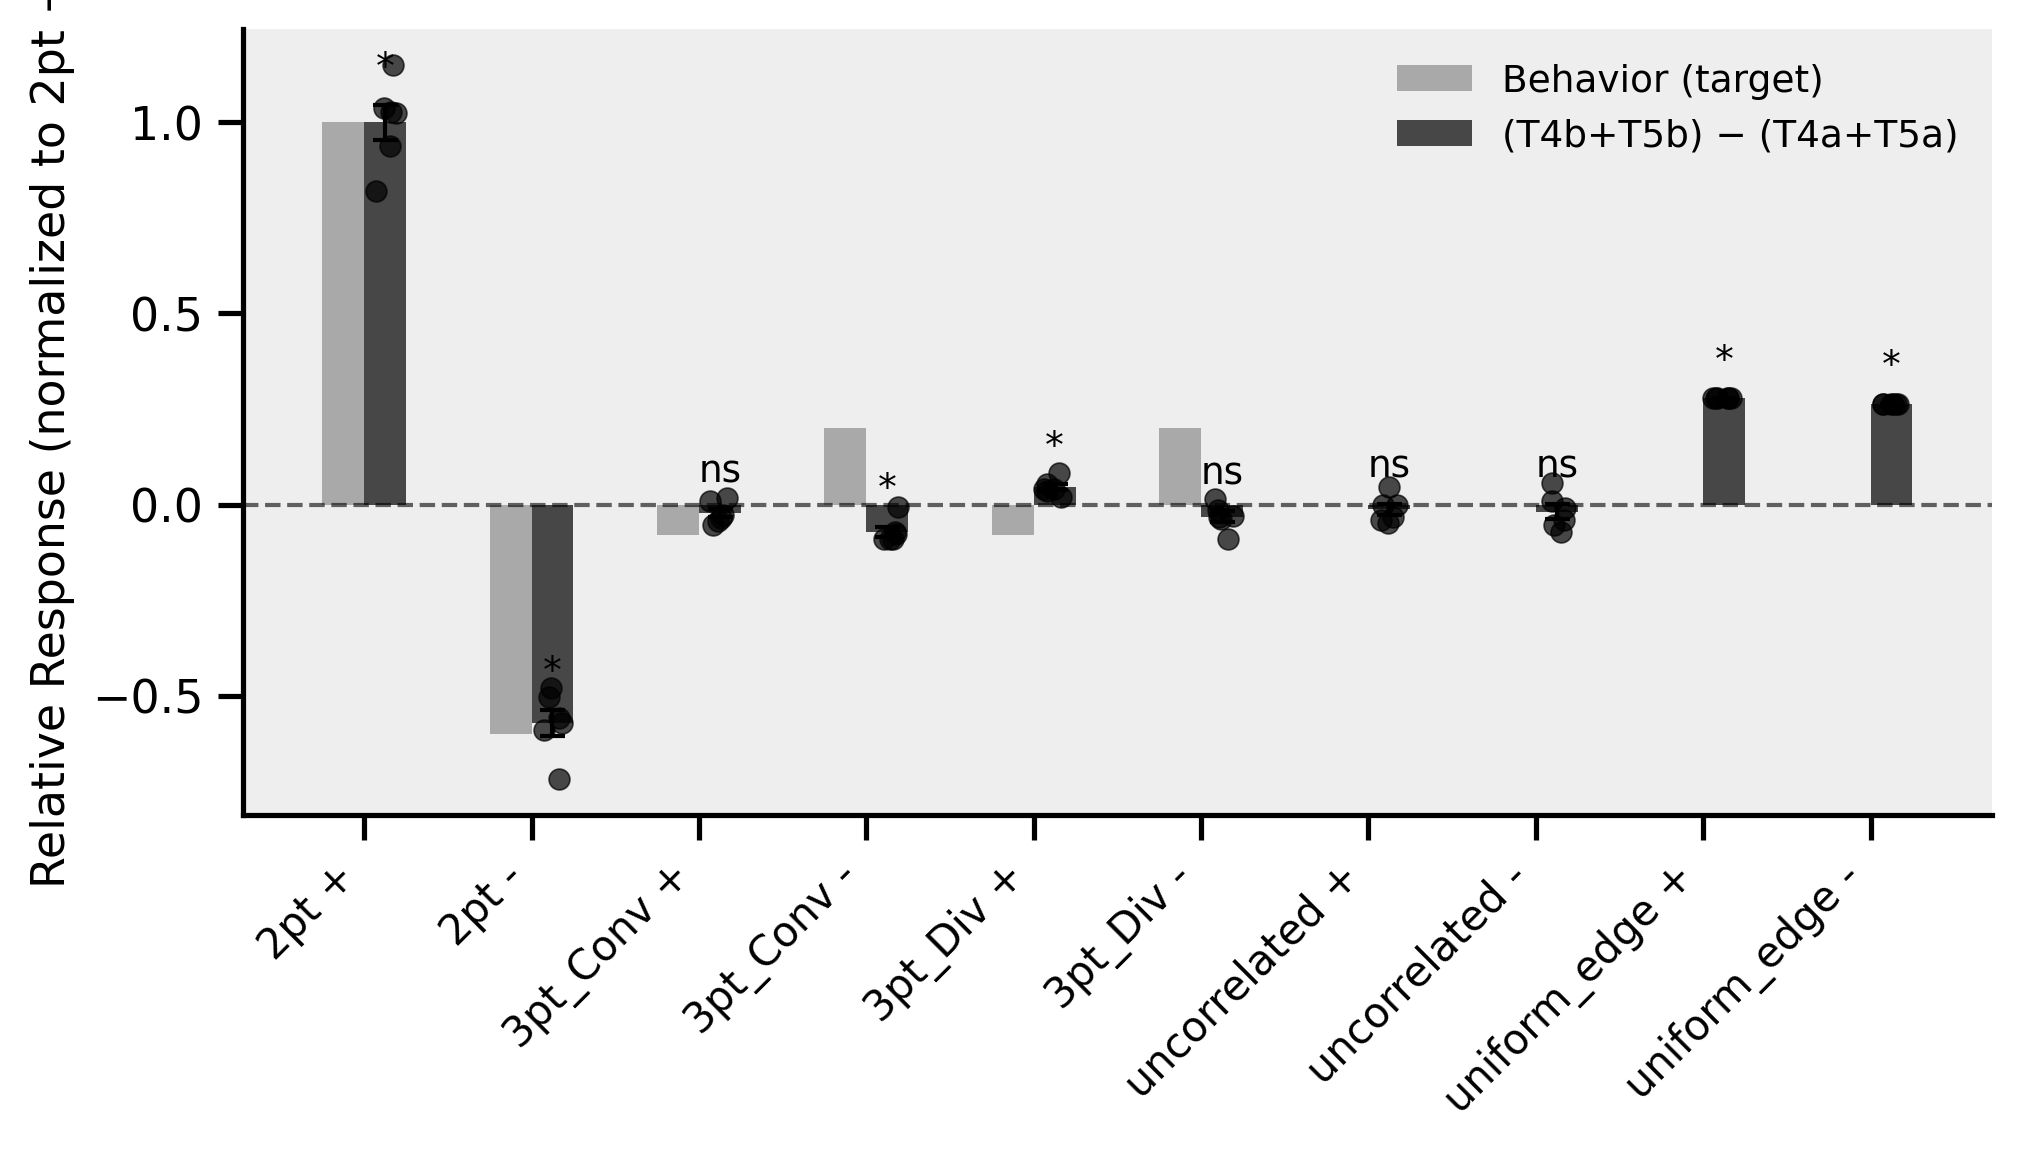

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ================================================================
# 1. Label rule + parity for grouping
# ================================================================
parity_map = {1: '+', -1: '-'}
stats_df["rule_parity"] = stats_df["rule"] + ' ' + stats_df["parity"].map(parity_map)

# ================================================================
# 2. Normalization (baseline: 2pt +)
# ================================================================
baseline = stats_df.loc[stats_df["rule_parity"] == "2pt +", "HSS_diff"].mean()
if np.isnan(baseline):
    baseline = 1.0
stats_df["HSS_diff_norm"] = stats_df["HSS_diff"] / baseline

# ================================================================
# 3. Aggregate across seeds (mean ± SEM)
# ================================================================
summary = (
    stats_df
    .groupby("rule_parity", as_index=False)
    .agg({
        "HSS_diff_norm": ["mean", "sem"],
    })
)

# Flatten multi-index columns
summary.columns = [
    "rule_parity",
    "HSS_mean", "HSS_sem"
]

# ================================================================
# 4. Wilcoxon signed-rank test (vs 0)
# ================================================================
def p_to_star(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

pvals = []
for rp in summary["rule_parity"]:
    subset = stats_df.query("rule_parity == @rp")
    try:
        _, p_hss = wilcoxon(subset["HSS_diff_norm"], alternative="two-sided", zero_method="wilcox")
    except ValueError:
        p_hss = np.nan
    pvals.append({"rule_parity": rp, "p_hsn": p_hsn, "p_hss": p_hss})

pvals_df = pd.DataFrame(pvals)

print(f"\n=== Wilcoxon Signed-Rank Test (vs 0, N={len(stats_df['seed'].unique())} seeds) ===")
print(f"{'rule_parity':<15}{'HSN':<10}{'HSS':<10}")
print("-" * 35)
for _, row in pvals_df.iterrows():
    print(f"{row['rule_parity']:<15}{p_to_star(row['p_hss']):<10}")

# ================================================================
# 5. PLOTTING (Bars + SEM + Scatter + significance)
# ================================================================
# ================================================================
# 5. PLOTTING (Bars + SEM + Scatter + significance)
# ================================================================
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
x = np.arange(len(summary))
width = 0.25

color_behavior = "darkgray"   # behavior (target)
color_model    = "k"          # model (HSS)
rng = np.random.default_rng(42)

# --- Align behavior vector to your summary order ---
target_vals = [target_behavior.get(rp, np.nan) for rp in summary["rule_parity"]]

# --- Bars for behavior and model ---
ax.bar(x - width/2, target_vals, width,
       color=color_behavior, alpha=1, label="Behavior (target)")
ax.bar(x + width/2, summary["HSS_mean"], width,
       color=color_model, alpha=0.7, label="(T4b+T5b) − (T4a+T5a)")

# --- Error bars (SEM) ---
ax.errorbar(x + width/2, summary["HSS_mean"], yerr=summary["HSS_sem"],
            fmt="none", ecolor="k", elinewidth=1, capsize=3, zorder=3)

# --- Scatter points for each seed ---
for i, rp in enumerate(summary["rule_parity"]):
    subset = stats_df.query("rule_parity == @rp")
    jitter = rng.uniform(-0.07, 0.07, size=len(subset))
    ax.scatter(np.full(len(subset), x[i] + width/2) + jitter,
               subset["HSS_diff_norm"],
               color=color_model, s=25, edgecolor="k", linewidth=0.4,
               alpha=0.7, zorder=4)

# --- Annotate significance stars ---
for i, rp in enumerate(summary["rule_parity"]):
    y_max = summary.loc[i, "HSS_mean"] + summary.loc[i, "HSS_sem"]
    y_text = y_max + 0.05
    p_entry = pvals_df.loc[pvals_df["rule_parity"] == rp].iloc[0]
    label = f"{p_to_star(p_entry['p_hss'])}"
    ax.text(x[i] + width/2, y_text, label, ha="center", va="bottom", fontsize=9)

# ================================================================
# 6. Formatting
# ================================================================
ax.set_xticks(x)
ax.set_xticklabels(summary["rule_parity"], rotation=45, ha="right", fontsize=10)
ax.axhline(0, color="k", linestyle="--", lw=1, alpha=0.6)
ax.set_ylabel("Relative Response (normalized to 2pt +)", fontsize=11)
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.set_facecolor("#EEEEEE")
plt.tight_layout()
plt.show()


== Per-seed optimal weights ==
   seed  w_T4_exc  w_T4_inh  w_T5_exc  w_T5_inh  final_cost
0     1  1.841056  0.000000  5.000000  0.000000    0.004337
1    20  0.881682  0.324713  3.129877  0.180359    0.017876
2    30  1.386447  0.000000  3.583010  0.000000    0.001737
3    55  1.320694  0.814311  4.031656  0.000000    0.020450
4    65  1.270040  0.281090  2.634509  0.000000    0.018725
5    67  1.046393  0.686918  3.350515  0.000000    0.011674

== Aggregate predictions vs targets (normalized to 2pt +) ==
  rule_parity  pred_mean      pred_sem  target
0       2pt +   1.000000  9.652066e-10    1.00
1       2pt -  -0.546496  2.391562e-02   -0.60
2  3pt_Conv +  -0.070136  3.332299e-02   -0.08
3  3pt_Conv -   0.125360  3.003747e-02    0.20
4   3pt_Div +   0.011647  2.680108e-02   -0.08
5   3pt_Div -   0.022436  4.432992e-02    0.20


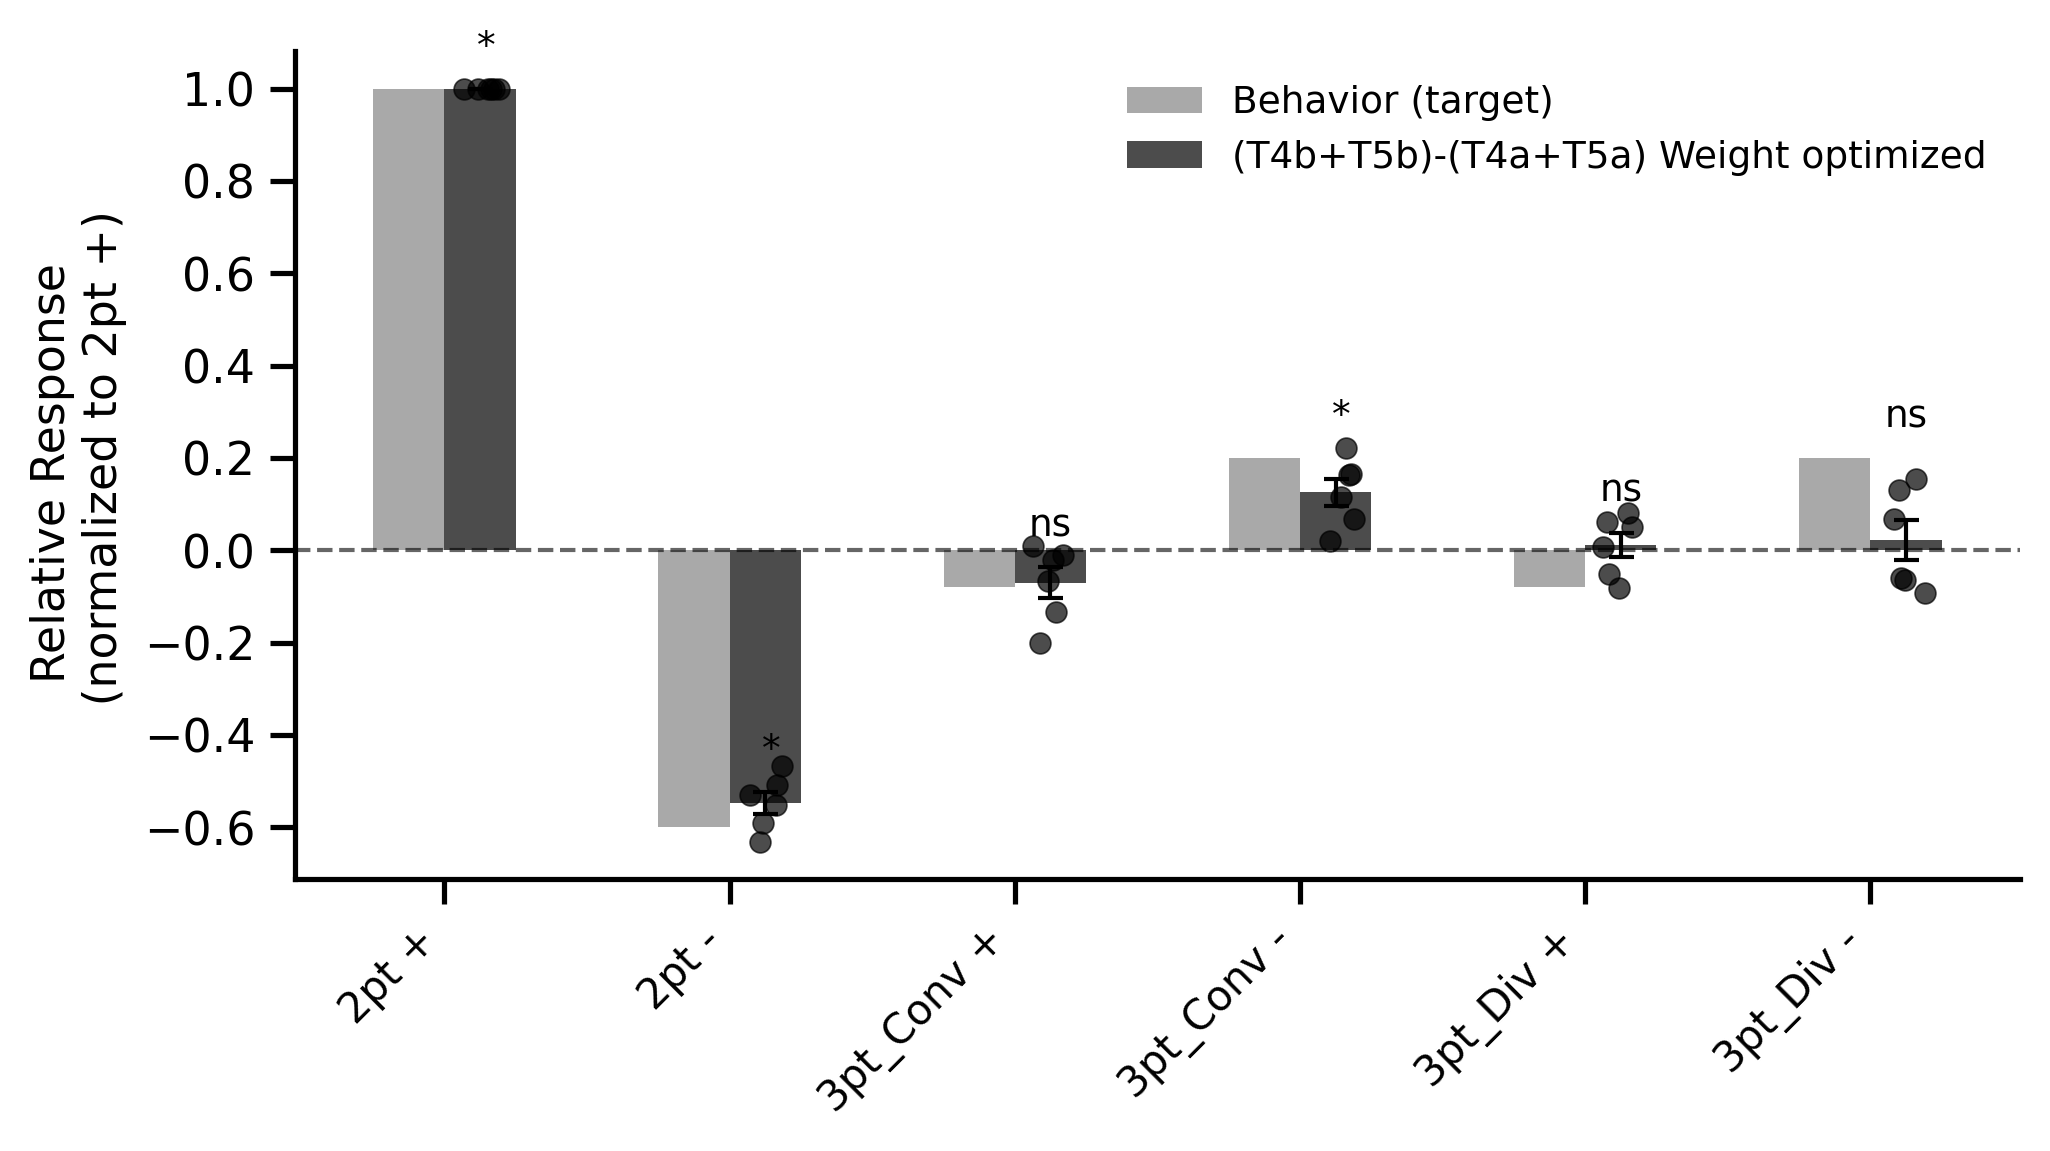

In [ ]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize


def collect_mean_traces_for_seed(seed_idx, seed):
    cache_seed = {}
    for rule in rules:
        for parity in parities:
            # PD/ND (R/L) rows
            qR = df.query("rule == @rule and direction == 'pd' and parity == @parity and seed == @seed")
            qL = df.query("rule == @rule and direction == 'nd' and parity == @parity and seed == @seed")
            assert len(qR) == 1 and len(qL) == 1, "Expected exactly one row per (seed,rule,parity) for PD/ND"

            right_idx = int(qR["sequence_idx"].iloc[0])
            left_idx  = int(qL["sequence_idx"].iloc[0])

            act_T4a_R, act_T4a_L, act_T4b_R, act_T4b_L = [], [], [], []
            act_T5a_R, act_T5a_L, act_T5b_R, act_T5b_L = [], [], [], []

            for neuron in band_indices:
                T4a_resp_R = T4a[seed_idx, right_idx, :, neuron]
                T4a_resp_L = T4a[seed_idx, left_idx,  :, neuron]
                T4b_resp_R = T4b[seed_idx, right_idx, :, neuron]
                T4b_resp_L = T4b[seed_idx, left_idx,  :, neuron]
                T5a_resp_R = T5a[seed_idx, right_idx, :, neuron]
                T5a_resp_L = T5a[seed_idx, left_idx,  :, neuron]
                T5b_resp_R = T5b[seed_idx, right_idx, :, neuron]
                T5b_resp_L = T5b[seed_idx, left_idx,  :, neuron]

                act_T4a_R.append(T4a_resp_R); act_T4a_L.append(T4a_resp_L)
                act_T4b_R.append(T4b_resp_R); act_T4b_L.append(T4b_resp_L)
                act_T5a_R.append(T5a_resp_R); act_T5a_L.append(T5a_resp_L)
                act_T5b_R.append(T5b_resp_R); act_T5b_L.append(T5b_resp_L)

            # mean across neurons → (time,)
            T4a_R_mean, T4a_L_mean = np.mean(act_T4a_R, 0), np.mean(act_T4a_L, 0)
            T4b_R_mean, T4b_L_mean = np.mean(act_T4b_R, 0), np.mean(act_T4b_L, 0)
            T5a_R_mean, T5a_L_mean = np.mean(act_T5a_R, 0), np.mean(act_T5a_L, 0)
            T5b_R_mean, T5b_L_mean = np.mean(act_T5b_R, 0), np.mean(act_T5b_L, 0)

            cache_seed[(rule, parity)] = dict(
                T4a_R=T4a_R_mean, T4a_L=T4a_L_mean,
                T4b_R=T4b_R_mean, T4b_L=T4b_L_mean,
                T5a_R=T5a_R_mean, T5a_L=T5a_L_mean,
                T5b_R=T5b_R_mean, T5b_L=T5b_L_mean,
            )
    return cache_seed

# Precompute cache for all seeds
seed_list = list(df["seed"].unique())
all_caches = {}
for seed_idx, seed in enumerate(seed_list):
    all_caches[seed] = collect_mean_traces_for_seed(seed_idx, seed)

# ------------------------------------------------------------
# 3) Given a seed + weights, compute per-condition HSS_diff_norm
# ------------------------------------------------------------
def seed_predictions(weights, cache_seed, smooth_sigma=2, eps=1e-9):
    w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh = weights
    preds = {}

    # First pass to get baseline (2pt +) for normalization
    if ("2pt", 1) not in cache_seed:
        # If missing baseline condition, skip normalization
        baseline_val = 1.0
    else:
        c = cache_seed[("2pt", 1)]
        # HSS for Right (PD) and Left (ND)
        _, _, HSS_R = compute_HS_responses_full(
            w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh,
            c["T4a_R"], c["T5a_R"], c["T4b_R"], c["T5b_R"]
        )
        _, _, HSS_L = compute_HS_responses_full(
            w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh,
            c["T4a_L"], c["T5a_L"], c["T4b_L"], c["T5b_L"]
        )
        HSS_R = gaussian_filter1d(HSS_R, smooth_sigma)
        HSS_L = gaussian_filter1d(HSS_L, smooth_sigma)
        baseline_val = (np.mean(HSS_R) - np.mean(HSS_L))
        if np.isclose(baseline_val, 0.0):
            baseline_val = 1.0

    # Now compute all rule/parity predictions, normalized to 2pt +
    for rule, parity in cache_seed.keys():
        if f"{rule} {'+' if parity==1 else '-'}" not in valid_conditions:
            continue
        c = cache_seed[(rule, parity)]
        _, _, HSS_R = compute_HS_responses_full(
            w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh,
            c["T4a_R"], c["T5a_R"], c["T4b_R"], c["T5b_R"]
        )
        _, _, HSS_L = compute_HS_responses_full(
            w_T4_exc, w_T4_inh, w_T5_exc, w_T5_inh,
            c["T4a_L"], c["T5a_L"], c["T4b_L"], c["T5b_L"]
        )
        HSS_R = gaussian_filter1d(HSS_R, smooth_sigma)
        HSS_L = gaussian_filter1d(HSS_L, smooth_sigma)
        pred = (np.mean(HSS_R) - np.mean(HSS_L)) / (baseline_val + eps)
        preds[f"{rule} {'+' if parity==1 else '-'}"] = pred

    return preds

# ------------------------------------------------------------
# 4) Per-seed objective and optimization
# ------------------------------------------------------------
def objective_for_seed(weights, cache_seed, targets, l2=0.0):
    preds = seed_predictions(weights, cache_seed)
    # MSE over the intersection of targets & preds
    keys = [k for k in targets.keys() if k in preds]
    if not keys:
        return 0.0
    err = np.mean([(preds[k] - targets[k])**2 for k in keys])
    if l2 > 0:
        err += l2 * np.sum(np.square(weights))
    return err

bounds = [(0.0, 5.0),  # w_T4_exc
          (0.0, 5.0),  # w_T4_inh
          (0.0, 5.0),  # w_T5_exc
          (0.0, 5.0)]  # w_T5_inh
x0 = np.array([1.0, 1.0, 1.0, 1.0])
l2_reg = 0.0  # set small >0 if you want to discourage extreme weights

results = []
pred_rows = []

for seed in seed_list:
    cache_seed = all_caches[seed]

    res = minimize(
        objective_for_seed,
        x0=x0,
        args=(cache_seed, target_behavior, l2_reg),
        method="L-BFGS-B",
        bounds=bounds,
    )

    wopt = res.x
    final_cost = res.fun
    preds = seed_predictions(wopt, cache_seed)

    # store weights + fit
    results.append({
        "seed": seed,
        "w_T4_exc": wopt[0],
        "w_T4_inh": wopt[1],
        "w_T5_exc": wopt[2],
        "w_T5_inh": wopt[3],
        "final_cost": final_cost
    })

    # store per-condition predictions for this seed
    for rp, val in preds.items():
        pred_rows.append({"seed": seed, "rule_parity": rp, "pred_norm": val, "target": target_behavior[rp]})

weights_df = pd.DataFrame(results).sort_values("seed").reset_index(drop=True)
pred_df = pd.DataFrame(pred_rows)

print("== Per-seed optimal weights ==")
print(weights_df)

# ------------------------------------------------------------
# 5) Aggregate predictions across seeds (mean±SEM) and compare to targets
# ------------------------------------------------------------
agg = (pred_df
       .groupby("rule_parity", as_index=False)
       .agg(pred_mean=("pred_norm", "mean"),
            pred_sem =("pred_norm", "sem"),
            target   =("target", "first"))
      ).sort_values("rule_parity")

print("\n== Aggregate predictions vs targets (normalized to 2pt +) ==")
print(agg)

## ------------------------------------------------------------
## 6) (Optional) quick visualization
## ------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ================================================================
# 1. Wilcoxon test per condition (vs 0) for predicted responses
# ================================================================
pvals = []
for rp in agg["rule_parity"]:
    subset = pred_df.query("rule_parity == @rp")
    try:
        _, p_hss = wilcoxon(subset["pred_norm"], alternative="two-sided", zero_method="wilcox")
    except ValueError:
        p_hss = np.nan
    pvals.append({"rule_parity": rp, "p_hss": p_hss})

pvals_df = pd.DataFrame(pvals)
def p_to_star(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "  ***"
    elif p < 0.01: return " **"
    elif p < 0.05: return " *"
    else: return "ns"

# ================================================================
# 2. Figure setup (matching your old style)
# ================================================================
fig, ax = plt.subplots(figsize=(7,4), dpi=150)
x = np.arange(len(agg))
width = 0.25

color_target = "darkgray"
color_pred   = "k"

# --- Bars for means ---
ax.bar(x - width/2, agg["target"], width,
       color=color_target, alpha=1, label="Behavior (target)")
ax.bar(x + width/2, agg["pred_mean"], width,
       color=color_pred, alpha=0.7, label="(T4b+T5b)-(T4a+T5a) Weight optimized")

# --- Error bars (SEM) ---
ax.errorbar(x + width/2, agg["pred_mean"], yerr=agg["pred_sem"],
            fmt="none", ecolor="k", elinewidth=1, capsize=3, zorder=3)

# --- Scatter points for each seed ---
rng = np.random.default_rng(42)
for i, rp in enumerate(agg["rule_parity"]):
    subset = pred_df.query("rule_parity == @rp")
    jitter = rng.uniform(-0.07, 0.07, size=len(subset))
    ax.scatter(np.full(len(subset), x[i] + width/2) + jitter,
               subset["pred_norm"],
               color=color_pred, s=25, edgecolor="k", linewidth=0.4,
               alpha=0.7, zorder=4)

# --- Annotate significance stars ---
for i, rp in enumerate(agg["rule_parity"]):
    y_max = max(agg.loc[i, "pred_mean"] + agg.loc[i, "pred_sem"],
                agg.loc[i, "target"])
    y_text = y_max + 0.05
    p_entry = pvals_df.loc[pvals_df["rule_parity"] == rp].iloc[0]
    ax.text(x[i]+width/2, y_text, p_to_star(p_entry["p_hss"]),
            ha="center", va="bottom", fontsize=9)

# ================================================================
# 3. Formatting
# ================================================================
ax.set_xticks(x)
ax.set_xticklabels(agg["rule_parity"], rotation=45, ha="right", fontsize=10)
ax.axhline(0, color="k", linestyle="--", lw=1, alpha=0.6)
ax.set_ylabel("Relative Response \n (normalized to 2pt +)", fontsize=11)
ax.legend(loc='upper right', frameon=False, fontsize=9)
# ax.set_facecolor("#EEEEEE1C")
plt.tight_layout()
plt.show()

